In [30]:
import quantstats as qs
import pandas as pd
import yfinance as yf

In [3]:
rets = qs.utils.download_returns('AAPL')
benchmark = qs.utils.download_returns('SPY')

In [9]:
qs.stats.sharpe(rets)

np.float64(-0.0441774568884672)

In [10]:
qs.stats.max_drawdown(rets)

np.float64(-0.8180144262089896)

In [11]:
qs.stats.value_at_risk(rets)

np.float64(-0.0441774568884672)

In [12]:
qs.stats.greeks(rets, benchmark).to_dict()

{'beta': 1.1033391278695486, 'alpha': 0.1763507453305373}

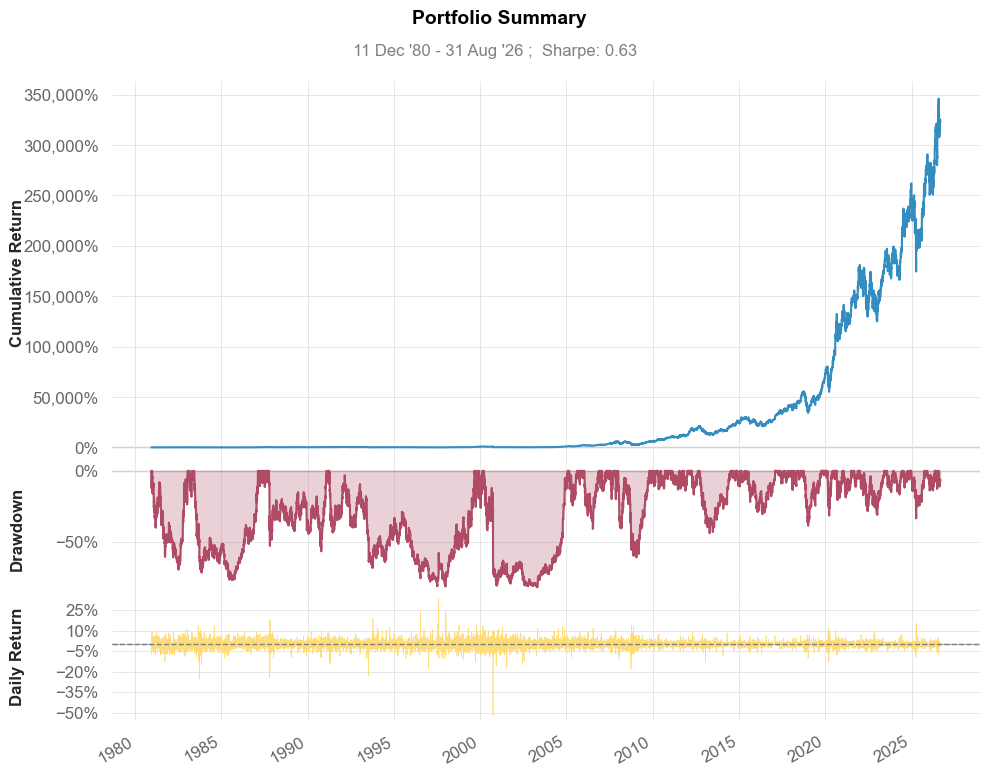

In [15]:
qs.plots.snapshot(rets)

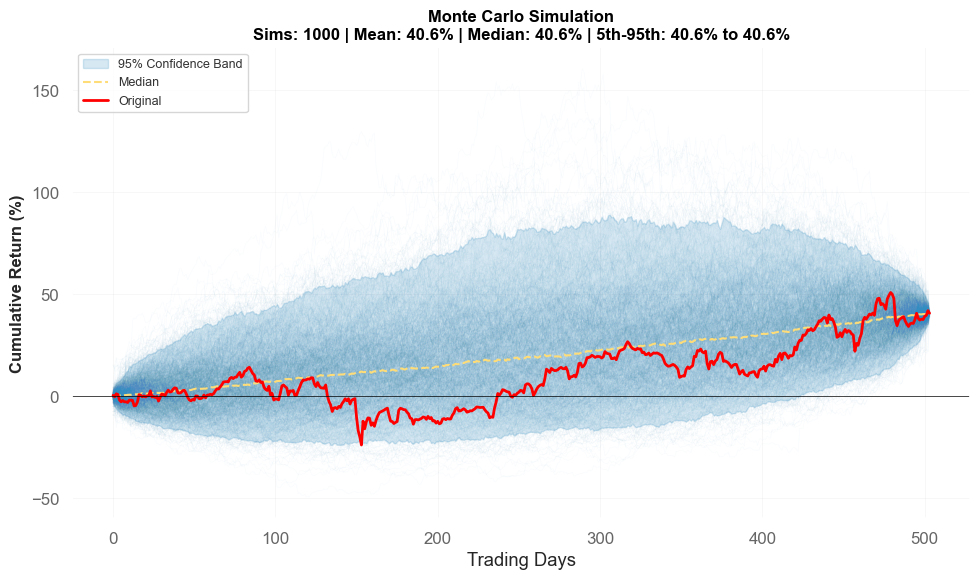

In [18]:
qs.plots.montecarlo(rets.tail(504), sims=1000)

In [20]:
qs.reports.html(rets, benchmark, title='AAPL vs SP500', output='reportaapl.html')

In [26]:
por = {'AAPL': .5, 'MSFT': .5}

poret = pd.DataFrame({
    ticker: qs.utils.download_returns(ticker) for ticker in por
}).dropna()

port = (poret * pd.Series(por)).sum(axis=1).rename('Portfolio')
sp = qs.utils.download_returns('SPY').rename('SP500')


In [28]:
qs.reports.html(port, sp, output='portfolioreport.html', title='port vs market')